# <center>Logistic Regression From Scratch<center>

## Table of Contents
1. Gradient descent
2. Stochastic gradient descent
3. Mini-batch gradient descent

---

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gradient_descent import cross_entropy

#### Importing data

In [2]:

import os
os.path.abspath(os.path.join(os.path.dirname('02_logistic_regression'), '..'))

bezdekIris = '../data/iris/bezdekIris.data'
df = pd.read_csv(bezdekIris)

---

#### Checking and filtring data

In [3]:
df

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

df = pd.read_csv(bezdekIris, header=None, names=column_names)

df

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
df['class'].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
mapping = {
    'Iris-setosa': 1, 
    'Iris-versicolor': 0, 
    'Iris-virginica': 0
}

df['class'] = df['class'].replace(mapping)

df

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,0
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


---

#### Visualizing data

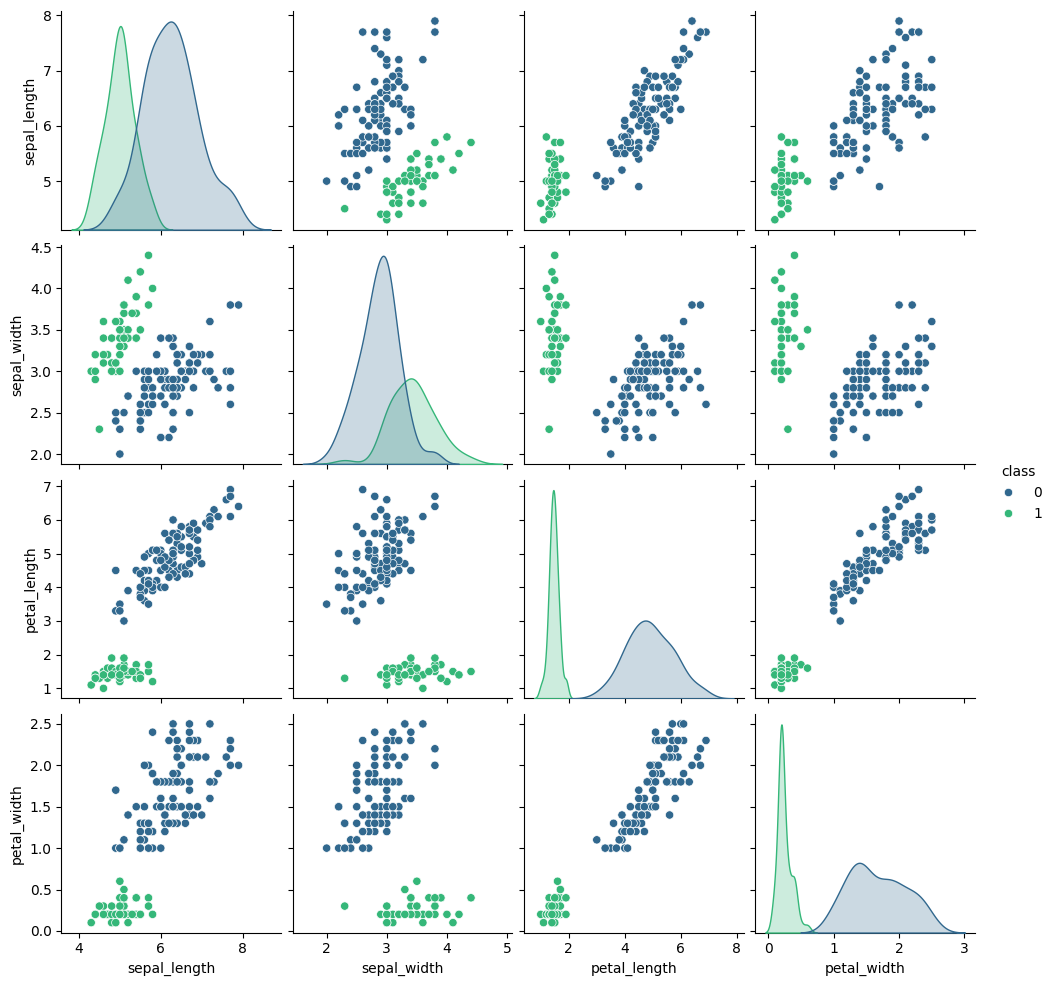

In [7]:
sns.pairplot(data=df, hue='class', palette='viridis')

---

### **Gradient descent**

Final loss: [0.31041648]


Text(0.5, 1.0, 'Logistic regression using gradient descent')

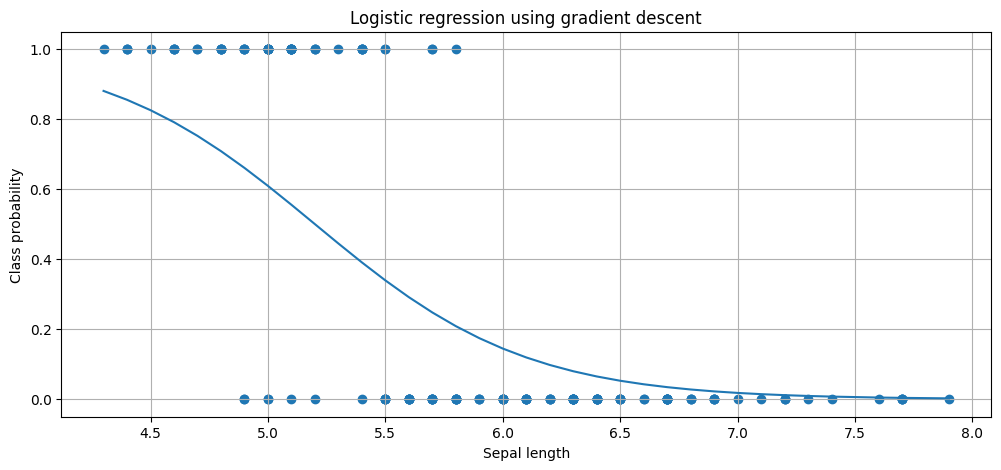

In [8]:
from gradient_descent import Logistic_Regression_GradientDescent

df_sorted = df[['sepal_length', 'class']].sort_values('sepal_length')

X = df_sorted['sepal_length'].to_numpy()
y = df_sorted['class'].to_numpy()

gradient_descent = Logistic_Regression_GradientDescent()

gradient_descent.fit(X, y, max_iters=1000, lr=0.44, stats=False)
y_pred = gradient_descent.predict_probability(X)

print(f'Final loss: {cross_entropy(y, y_pred)}')

plt.figure(figsize=(12, 5))
plt.scatter(X, y, label='data')
plt.plot(X, y_pred, label='prediction')
plt.grid()
plt.xlabel('Sepal length')
plt.ylabel('Class probability')
plt.title('Logistic regression using gradient descent')

In [9]:
# === Learning rate test ===
X = df_sorted['sepal_length'].sort_values(ascending=False).to_numpy()
y = df_sorted['class'].to_numpy()

rates_test = np.linspace(0, 1, 50)

finals_loss = []
for rate in rates_test:
    rate_test = Logistic_Regression_GradientDescent()
    rate_test.fit(X, y, max_iters=500, lr=rate, stats=False)

    y_approx = rate_test.predict_probability(X)
    loss = cross_entropy(y, y_approx)
    
    finals_loss.append(loss)

Text(0.5, 1.0, 'Impact of learning rate on final cross entropy')

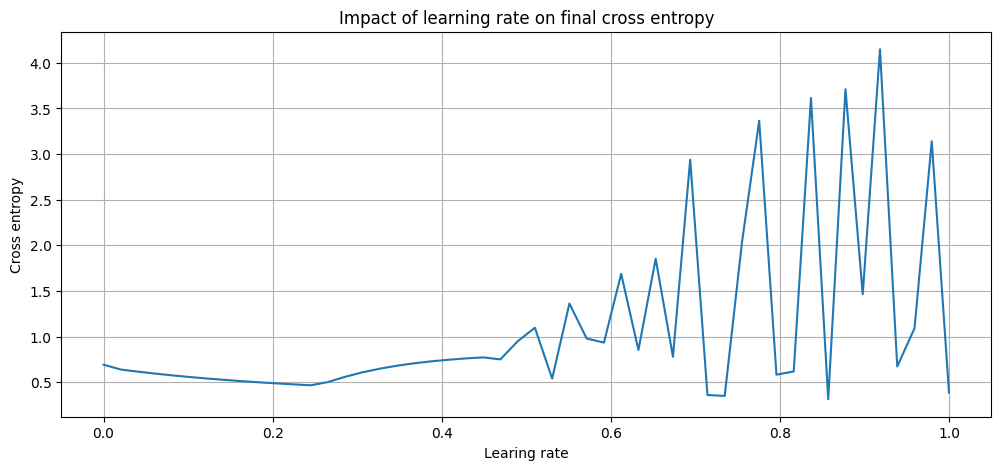

In [10]:
figlr, axlr = plt.subplots(figsize=(12, 5))
axlr.plot(rates_test, finals_loss)
axlr.grid()
axlr.set_xlabel('Learing rate')
axlr.set_ylabel('Cross entropy')
axlr.set_title('Impact of learning rate on final cross entropy')

Text(0, 0.5, 'Cross entropy')

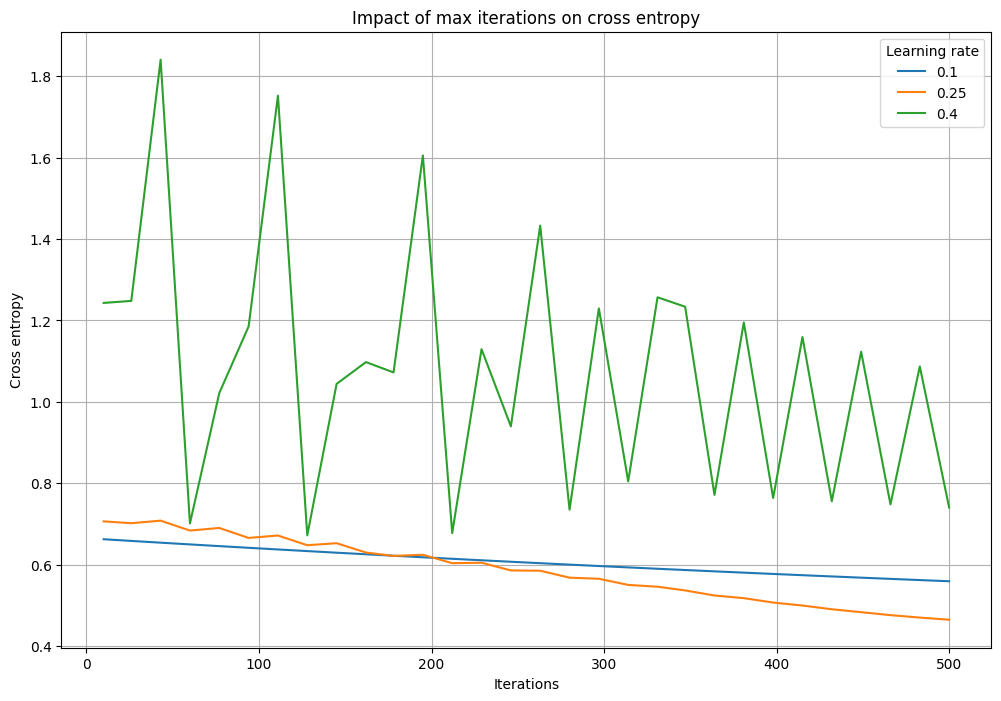

In [11]:
# === Iteration test ===
X = df_sorted['sepal_length'].sort_values(ascending=False).to_numpy()
y = df_sorted['class'].to_numpy()

iterations = np.linspace(10, 500, 30, dtype=int)
rates = [0.1, 0.25, 0.4]

figit, axit = plt.subplots(figsize=(12, 8))

for rate in rates:
    curr_loss = []
    for iter in iterations:
        iter_test = Logistic_Regression_GradientDescent()
        iter_test.fit(X, y, max_iters=iter, lr=rate, stats=False)
        y_approx = iter_test.predict_probability(X)
        loss = cross_entropy(y, y_approx)
        
        curr_loss.append(loss)
    
    axit.plot(iterations, curr_loss, label=str(rate))

axit.grid()
axit.legend(title='Learning rate')
axit.set_title('Impact of max iterations on cross entropy')
axit.set_xlabel('Iterations')
axit.set_ylabel('Cross entropy')

---

### **Stochastic gradient descent**

Text(0, 0.5, 'Class')

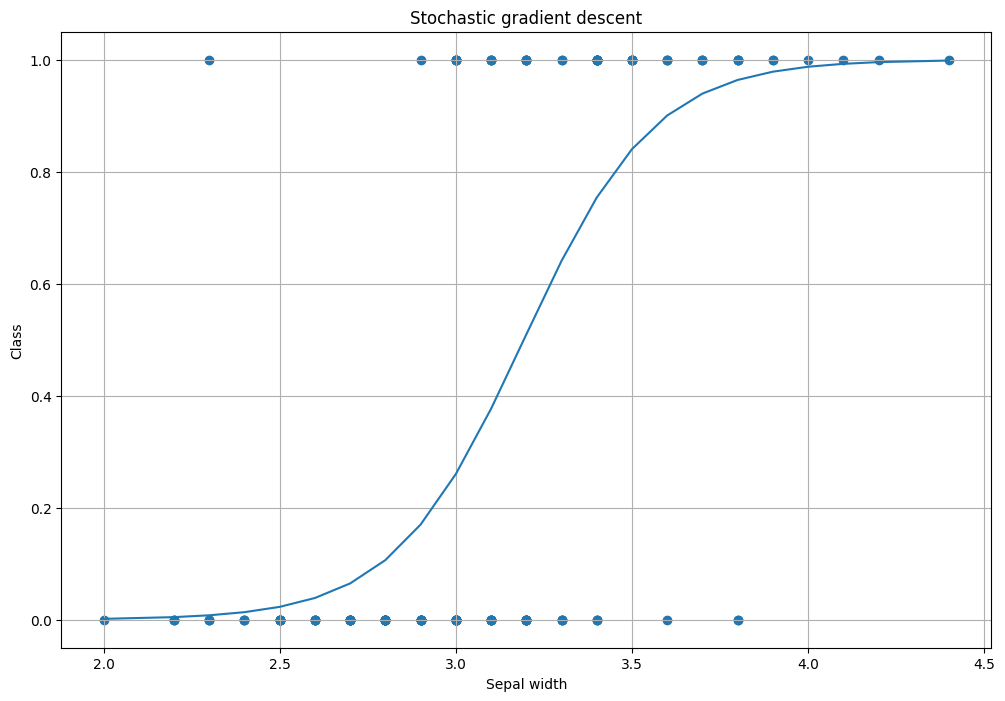

In [12]:
from stochastick_gd import Logistic_Regression_SG

df_sorted = df[['sepal_width', 'class']].sort_values('sepal_width')

X = df_sorted['sepal_width'].to_numpy()
y = df_sorted['class'].to_numpy()

stochastic = Logistic_Regression_SG()
stochastic.fit(X, y, max_iters=500, lr=0.1, stats=False)
y_pred = stochastic.predict_probability(X)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(X, y, label='data')
ax.plot(X, y_pred, label='prediction')
ax.grid()
ax.set_title('Stochastic gradient descent')
ax.set_xlabel('Sepal width')
ax.set_ylabel('Class')

In [13]:
# === Learning rate test ===
df_sorted = df[['sepal_width', 'class']].sort_values('sepal_width')
X = df_sorted['sepal_width'].to_numpy()
y = df_sorted['class'].to_numpy()

rates_test_sgd = np.linspace(0, 1, 50)

finals_loss_sgd = []
for rate in rates_test_sgd:
    rate_test_sgd = Logistic_Regression_SG()
    rate_test_sgd.fit(X, y, max_iters=500, lr=rate, stats=False)

    y_approx = rate_test_sgd.predict_probability(X)
    loss = cross_entropy(y, y_approx)
    
    finals_loss_sgd.append(loss)

Text(0.5, 1.0, 'Impact of learning rate on final cross entropy')

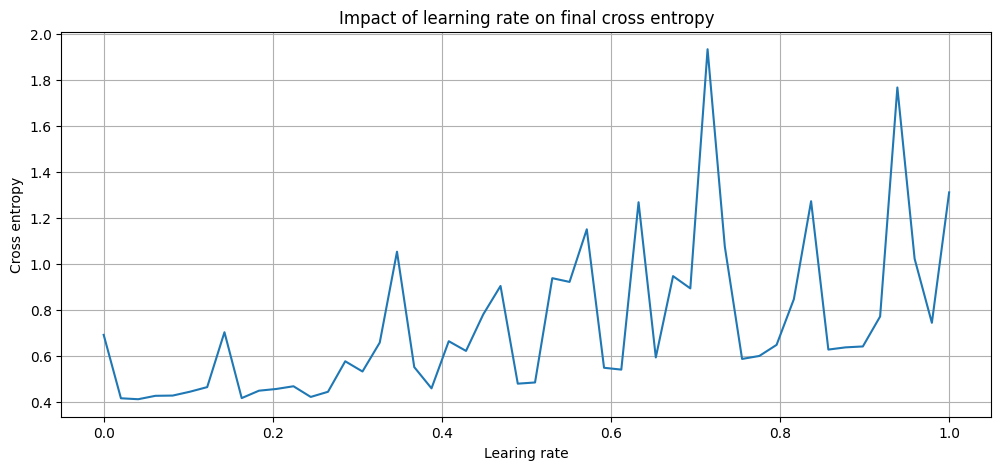

In [14]:
figsgd, axsgd = plt.subplots(figsize=(12, 5))
axsgd.plot(rates_test_sgd, finals_loss_sgd)
axsgd.grid()
axsgd.set_xlabel('Learing rate')
axsgd.set_ylabel('Cross entropy')
axsgd.set_title('Impact of learning rate on final cross entropy')

Text(0, 0.5, 'Cross entropy')

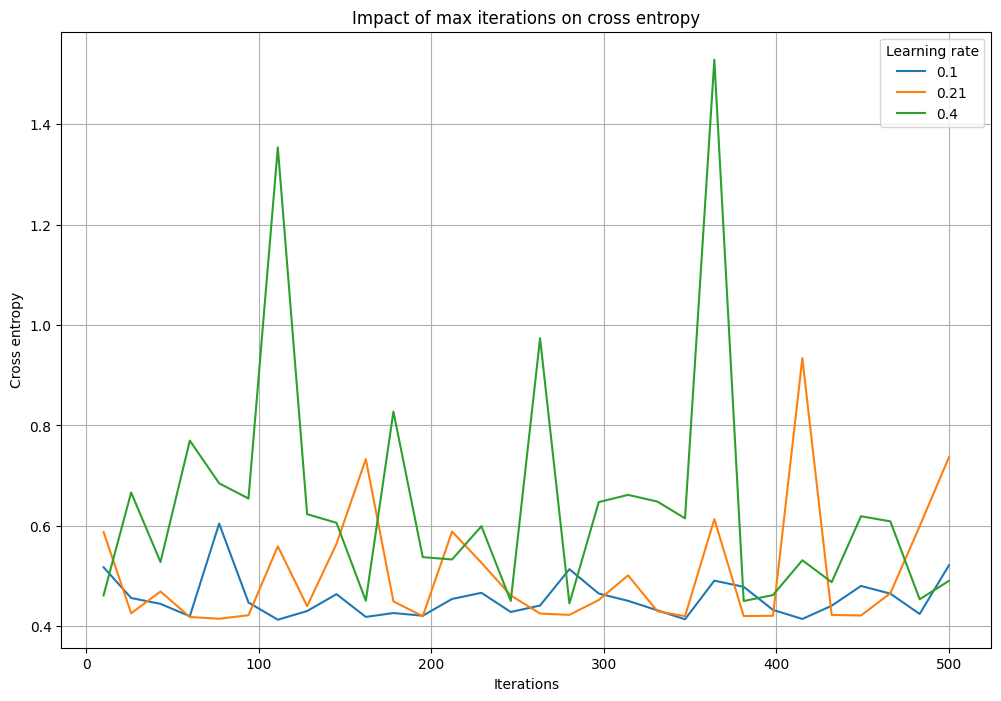

In [15]:
# === Iteration test ===
df_sorted = df[['sepal_width', 'class']].sort_values('sepal_width')
X = df_sorted['sepal_width'].to_numpy()
y = df_sorted['class'].to_numpy()

iterations = np.linspace(10, 500, 30, dtype=int)
rates = [0.1, 0.21, 0.4]

figit, axit = plt.subplots(figsize=(12, 8))

for rate in rates:
    curr_loss = []
    for iter in iterations:
        iter_test = Logistic_Regression_SG()
        iter_test.fit(X, y, max_iters=iter, lr=rate, stats=False)
        y_approx = iter_test.predict_probability(X)
        loss = cross_entropy(y, y_approx)
        
        curr_loss.append(loss)
    
    axit.plot(iterations, curr_loss, label=str(rate))

axit.grid()
axit.legend(title='Learning rate')
axit.set_title('Impact of max iterations on cross entropy')
axit.set_xlabel('Iterations')
axit.set_ylabel('Cross entropy')

---

### **Mini batch gradient descent**

For 0 epoch
Loss: [0.42755742]
For 1 epoch
Loss: [0.40518925]
For 2 epoch
Loss: [0.39685973]
For 3 epoch
Loss: [0.36741535]
For 4 epoch
Loss: [0.35070903]
For 5 epoch
Loss: [0.33669467]
For 6 epoch
Loss: [0.33271251]
For 7 epoch
Loss: [0.32076552]
For 8 epoch
Loss: [0.29469384]
For 9 epoch
Loss: [0.2832168]
For 10 epoch
Loss: [0.27888888]
For 11 epoch
Loss: [0.26162918]
For 12 epoch
Loss: [0.25417036]
For 13 epoch
Loss: [0.24370433]
For 14 epoch
Loss: [0.23506795]
For 15 epoch
Loss: [0.22799819]
For 16 epoch
Loss: [0.22430545]
For 17 epoch
Loss: [0.21258328]
For 18 epoch
Loss: [0.20742386]
For 19 epoch
Loss: [0.19973185]
For 20 epoch
Loss: [0.19401289]
For 21 epoch
Loss: [0.18907754]
For 22 epoch
Loss: [0.18455649]
For 23 epoch
Loss: [0.17835577]
For 24 epoch
Loss: [0.17326465]
For 25 epoch
Loss: [0.16867888]
For 26 epoch
Loss: [0.16470289]
For 27 epoch
Loss: [0.16032782]
For 28 epoch
Loss: [0.15637719]
For 29 epoch
Loss: [0.152612]
For 30 epoch
Loss: [0.1491811]
For 31 epoch
Loss: [0.

Text(0, 0.5, 'Class')

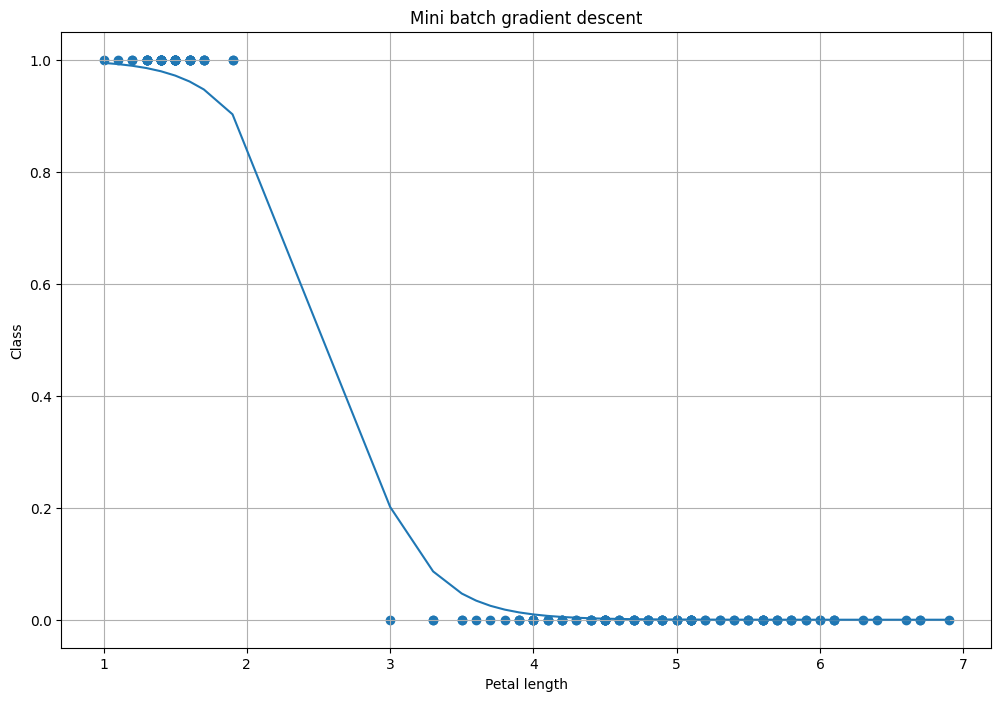

In [16]:
from mini_batch_gd import Logistic_Regression_MiniBatch

df_sorted = df[['petal_length', 'class']].sort_values('petal_length')

X = df_sorted['petal_length'].to_numpy()
y = df_sorted['class'].to_numpy()

mini_batch = Logistic_Regression_MiniBatch()
mini_batch.fit(X, y, max_iters=500, lr=0.2, stats=True)
y_pred = mini_batch.predict_probability(X)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(X, y, label='data')
ax.plot(X, y_pred, label='prediction')
ax.grid()
ax.set_title('Mini batch gradient descent')
ax.set_xlabel('Petal length')
ax.set_ylabel('Class')

In [17]:
# === Learning rate test ===
X = df_sorted['petal_length'].to_numpy()
y = df_sorted['class'].to_numpy()

rates_test = np.linspace(0, 1, 50)

finals_loss_batch = []
for rate in rates_test:
    rate_test = Logistic_Regression_MiniBatch()
    rate_test.fit(X, y, max_iters=500, lr=rate, stats=False)

    y_approx = rate_test.predict_probability(X)
    loss = cross_entropy(y, y_approx)
    
    finals_loss_batch.append(loss)

Text(0.5, 1.0, 'Impact of learning rate on final cross entropy')

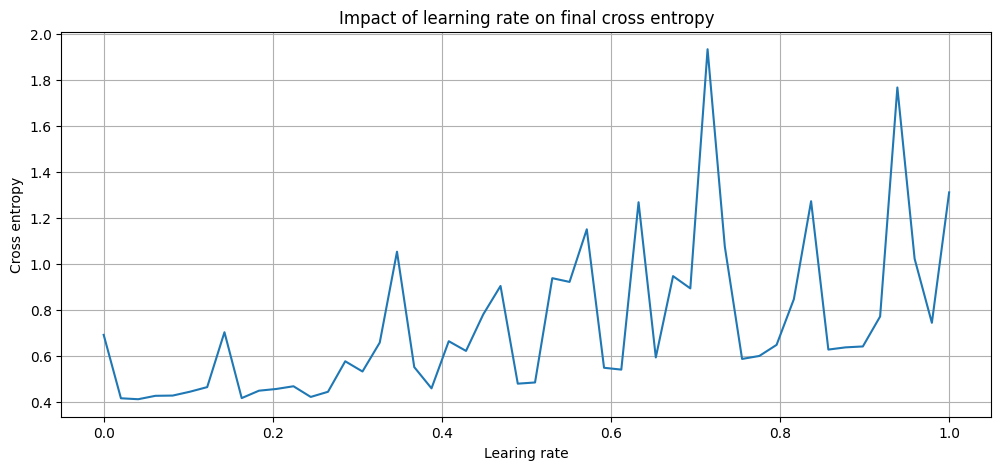

In [18]:
figsgd, axsgd = plt.subplots(figsize=(12, 5))
axsgd.plot(rates_test_sgd, finals_loss_sgd)
axsgd.grid()
axsgd.set_xlabel('Learing rate')
axsgd.set_ylabel('Cross entropy')
axsgd.set_title('Impact of learning rate on final cross entropy')

Text(0, 0.5, 'Cross entropy')

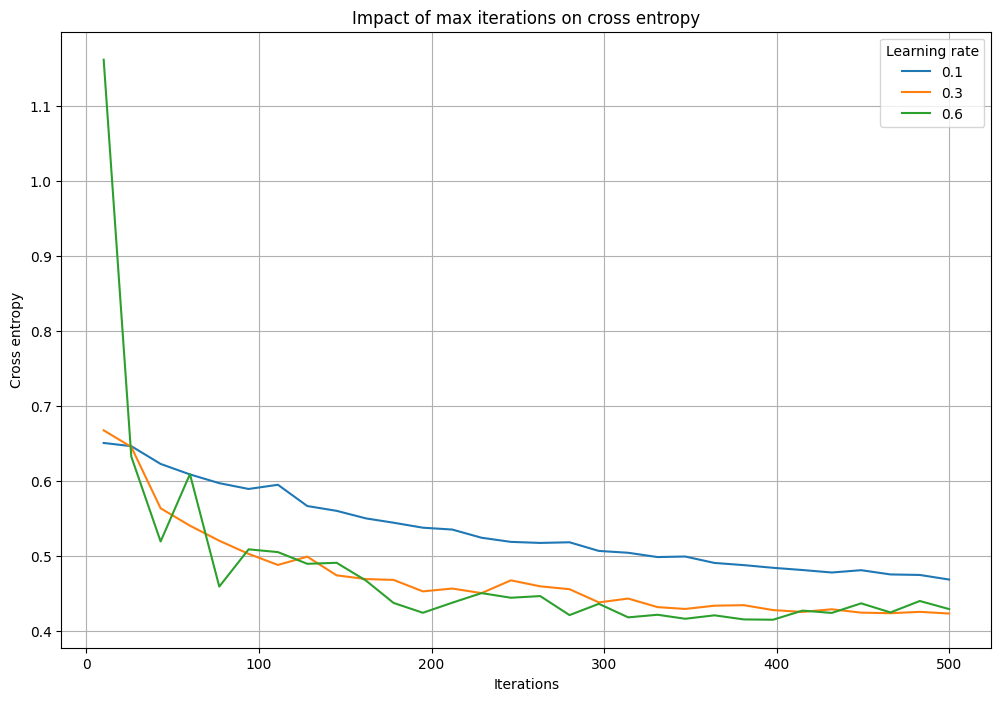

In [19]:
# === Iteration test ===
df_sorted = df[['sepal_width', 'class']].sort_values('sepal_width')
X = df_sorted['sepal_width'].to_numpy()
y = df_sorted['class'].to_numpy()

iterations = np.linspace(10, 500, 30, dtype=int)
rates = [0.1, 0.3, 0.6]

figit, axit = plt.subplots(figsize=(12, 8))

for rate in rates:
    curr_loss = []
    for iter in iterations:
        iter_test = Logistic_Regression_MiniBatch()
        iter_test.fit(X, y, max_iters=iter, lr=rate, stats=False)
        y_approx = iter_test.predict_probability(X)
        loss = cross_entropy(y, y_approx)
        
        curr_loss.append(loss)
    
    axit.plot(iterations, curr_loss, label=str(rate))

axit.grid()
axit.legend(title='Learning rate')
axit.set_title('Impact of max iterations on cross entropy')
axit.set_xlabel('Iterations')
axit.set_ylabel('Cross entropy')

---